# LangGraph 그래프 설계 문제: 검증과 재검색 루프

## 문제 목표

이 문제의 목표는 노드 내부 함수를 직접 구현하는 것이 아니다.

이미 제공된 노드를 사용해 **LangGraph 그래프를 설계할 수 있는지** 확인하는 것이다.

학생은 다음 내용을 완성한다.

1. 노드 등록
2. 기본 Edge 연결
3. 조건부 Edge 연결
4. 재검색 루프 연결
5. 종료 Edge 연결
6. 그래프 컴파일
7. 그래프 시각화

---

## 처음 만들어야 할 그래프

```mermaid
flowchart TD
    START([START]) --> SEARCH[검색]
    SEARCH --> VALIDATE[검증]

    VALIDATE -->|충분함| REPORT[리포트작성]
    VALIDATE -->|부족함| REWRITE[검색어재작성]

    REWRITE --> SEARCH
    REPORT --> END([END])
```

---

## 원본 노트북과의 관계

이 문제는 `07-3_langgraph_tavily_advanced_loop.ipynb`의 구조를 단순화한 것이다.

원본 노트북은 Tavily 검색과 LLM을 사용하지만, 이 문제에서는 외부 API 없이 실행되도록 검색·리포트 작성 로직을 단순화하였다.

따라서 수업에서는 LangGraph의 구조 설계에만 집중할 수 있다.


## 평가 기준

| 평가 항목 | 확인 내용 |
|---|---|
| State 이해 | 그래프 전체에서 공유되는 상태값을 설명할 수 있는가 |
| 노드 등록 | `검색`, `검증`, `검색어재작성`, `리포트작성` 노드를 모두 등록했는가 |
| 기본 Edge | `START → 검색 → 검증` 흐름을 연결했는가 |
| 조건부 Edge | `검증` 결과에 따라 다음 노드를 다르게 선택했는가 |
| 재검색 루프 | `검색어재작성 → 검색` 흐름을 연결했는가 |
| 종료 처리 | `리포트작성 → END`를 연결했는가 |
| 안전장치 | 최대 검색 횟수 도달 시 종료되는 구조를 이해했는가 |
| 실행 확인 | 최종 State에 `report`가 생성되는가 |


## 1. 기본 설정

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

MAX_SEARCH_COUNT = 2


## 2. State 정의

In [4]:
class AdvancedNewsState(TypedDict):
    """뉴스 검색 리포트 그래프에서 공유하는 State이다."""

    # 사용자가 입력한 원래 주제이다.
    topic: str

    # 현재 검색에 사용할 검색어이다.
    search_query: str

    # 현재 검색 결과 목록이다.
    search_results: list[dict]

    # 검색 결과가 리포트 작성에 충분한지 여부이다.
    is_sufficient: bool

    # 검증 결과나 재검색 이유이다.
    feedback: str

    # 검색이 몇 번 실행되었는지 저장한다.
    search_count: int

    # 최종 리포트이다.
    report: str


## 3. 그래프 시각화 함수

In [5]:
def show_graph(app) -> None:
    """LangGraph 구조를 시각화한다.

    1차: Mermaid PNG 이미지 출력
    2차: ASCII 그래프 출력
    3차: Mermaid 코드 텍스트 출력
    """
    graph = app.get_graph()

    try:
        display(Image(graph.draw_mermaid_png()))
        return
    except Exception as e:
        print(f"Mermaid PNG 생성 실패: {e}")

    try:
        print(graph.draw_ascii())
        return
    except Exception as e:
        print(f"ASCII 그래프 생성 실패: {e}")

    print("Mermaid 코드로 대체 출력한다.")
    print(graph.draw_mermaid())


## 4. 제공 노드

아래 노드들은 이미 완성되어 있다고 가정한다. 학생은 노드 내부를 수정하지 않는다.

In [6]:
def search_node(state: AdvancedNewsState) -> dict:
    """검색 노드이다.

    실제 Tavily API 대신 가짜 검색 결과를 반환한다.
    첫 번째 검색은 결과가 부족하고, 두 번째 검색은 결과가 충분하도록 구성되어 있다.
    """

    query = state.get("search_query") or state["topic"]
    search_count = state.get("search_count", 0) + 1

    print(f"[검색 #{search_count}] 검색어: {query}")

    if search_count == 1:
        results = [
            {
                "title": f"{query} 관련 짧은 기사",
                "url": "https://example.com/short",
                "content": "짧은 검색 결과"
            }
        ]
    else:
        results = [
            {
                "title": f"{query} 관련 기사 {i}",
                "url": f"https://example.com/article-{i}",
                "content": "충분한 기사 내용입니다. 실제 수업에서는 Tavily 검색 결과가 이 위치에 들어간다."
            }
            for i in range(1, 5)
        ]

    return {
        "search_query": query,
        "search_results": results,
        "search_count": search_count,
    }


def validate_node(state: AdvancedNewsState) -> dict:
    """검증 노드이다.

    검색 결과가 3개 이상이면 충분하다고 판단한다.
    단, 최대 검색 횟수에 도달하면 부족하더라도 리포트 작성 단계로 넘어가게 한다.
    """

    results = state["search_results"]
    search_count = state["search_count"]

    has_enough_results = len(results) >= 3
    reached_limit = search_count >= MAX_SEARCH_COUNT

    if has_enough_results:
        feedback = "검색 결과가 충분하다."
        is_sufficient = True

    elif reached_limit:
        feedback = "검색 결과가 부족하지만 최대 검색 횟수에 도달했으므로 리포트를 작성한다."
        is_sufficient = True

    else:
        feedback = "검색 결과가 부족하다. 검색어 재작성이 필요하다."
        is_sufficient = False

    print(f"[검증] 충분 여부: {is_sufficient} / {feedback}")

    return {
        "is_sufficient": is_sufficient,
        "feedback": feedback,
    }


def rewrite_query_node(state: AdvancedNewsState) -> dict:
    """검색어 재작성 노드이다.

    실제 LLM 대신 규칙 기반으로 검색어를 보완한다.
    """

    new_query = f"{state['topic']} 최신 동향 사례"

    print(f"[검색어재작성] 새 검색어: {new_query}")

    return {
        "search_query": new_query
    }


def report_node(state: AdvancedNewsState) -> dict:
    """리포트 작성 노드이다."""

    lines = [
        f"# 뉴스 리포트: {state['topic']}",
        "",
        f"- 최종 검색어: {state['search_query']}",
        f"- 검색 횟수: {state['search_count']}",
        f"- 검증 피드백: {state['feedback']}",
        "",
        "## 검색 결과 요약",
    ]

    for i, item in enumerate(state["search_results"], start=1):
        lines.append(f"{i}. {item['title']}")
        lines.append(f"   - URL: {item['url']}")
        lines.append(f"   - 내용: {item['content']}")

    report = "\n".join(lines)

    print("[리포트작성] 최종 리포트 생성 완료")

    return {
        "report": report
    }


## 그래프 구성 정답

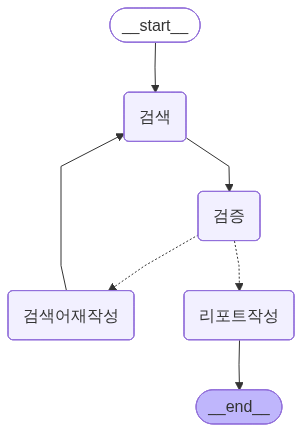

In [7]:
def route_after_validation(state: AdvancedNewsState) -> str:
    """검증 결과에 따라 다음 노드를 선택한다."""

    if state["is_sufficient"]:
        return "리포트작성"

    return "검색어재작성"


builder = StateGraph(AdvancedNewsState)

# 노드 등록
builder.add_node("검색", search_node)
builder.add_node("검증", validate_node)
builder.add_node("검색어재작성", rewrite_query_node)
builder.add_node("리포트작성", report_node)

# 기본 Edge
builder.add_edge(START, "검색")
builder.add_edge("검색", "검증")

# 조건부 Edge
builder.add_conditional_edges(
    "검증",
    route_after_validation,
    {
        "리포트작성": "리포트작성",
        "검색어재작성": "검색어재작성",
    },
)

# 재검색 루프
builder.add_edge("검색어재작성", "검색")

# 종료 Edge
builder.add_edge("리포트작성", END)

app = builder.compile()

show_graph(app)


## 그래프 시각화

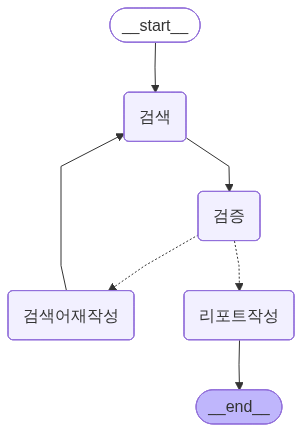

In [8]:
# 완성된 그래프의 Mermaid 코드를 출력한다.
# 환경에 따라 이미지 렌더링은 지원되지 않을 수 있다.
from IPython.display import Image, display

def show_graph(app) -> None:
    """LangGraph 구조를 시각화한다.

    Mermaid PNG 생성이 실패하면 ASCII 그래프로 대체한다.
    """
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())


show_graph(app)


## 실행 확인

그래프를 완성한 뒤 아래 코드를 실행한다.

첫 번째 검색은 결과가 부족하므로 `검색어재작성` 노드로 이동한다.

두 번째 검색에서는 결과가 충분하므로 `리포트작성` 노드로 이동한다.


In [9]:
initial_state: AdvancedNewsState = {
    "topic": "생성형 AI 교육 트렌드",
    "search_query": "",
    "search_results": [],
    "is_sufficient": False,
    "feedback": "",
    "search_count": 0,
    "report": "",
}

result = app.invoke(initial_state)

print("\n" + "=" * 70)
print("최종 State 확인")
print("=" * 70)
print("최종 검색어:", result["search_query"])
print("검색 횟수:", result["search_count"])
print("검증 피드백:", result["feedback"])

print("\n" + "=" * 70)
print("최종 리포트")
print("=" * 70)
print(result["report"])


[검색 #1] 검색어: 생성형 AI 교육 트렌드
[검증] 충분 여부: False / 검색 결과가 부족하다. 검색어 재작성이 필요하다.
[검색어재작성] 새 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
[검색 #2] 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
[검증] 충분 여부: True / 검색 결과가 충분하다.
[리포트작성] 최종 리포트 생성 완료

최종 State 확인
최종 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
검색 횟수: 2
검증 피드백: 검색 결과가 충분하다.

최종 리포트
# 뉴스 리포트: 생성형 AI 교육 트렌드

- 최종 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
- 검색 횟수: 2
- 검증 피드백: 검색 결과가 충분하다.

## 검색 결과 요약
1. 생성형 AI 교육 트렌드 최신 동향 사례 관련 기사 1
   - URL: https://example.com/article-1
   - 내용: 충분한 기사 내용입니다. 실제 수업에서는 Tavily 검색 결과가 이 위치에 들어간다.
2. 생성형 AI 교육 트렌드 최신 동향 사례 관련 기사 2
   - URL: https://example.com/article-2
   - 내용: 충분한 기사 내용입니다. 실제 수업에서는 Tavily 검색 결과가 이 위치에 들어간다.
3. 생성형 AI 교육 트렌드 최신 동향 사례 관련 기사 3
   - URL: https://example.com/article-3
   - 내용: 충분한 기사 내용입니다. 실제 수업에서는 Tavily 검색 결과가 이 위치에 들어간다.
4. 생성형 AI 교육 트렌드 최신 동향 사례 관련 기사 4
   - URL: https://example.com/article-4
   - 내용: 충분한 기사 내용입니다. 실제 수업에서는 Tavily 검색 결과가 이 위치에 들어간다.


## 실행 흐름 확인

`stream_mode="updates"`를 사용하면 각 노드가 어떤 순서로 실행되는지 확인할 수 있다.


In [10]:
for event in app.stream(initial_state, stream_mode="updates"):
    print(event)
    print("-" * 80)


[검색 #1] 검색어: 생성형 AI 교육 트렌드
{'검색': {'search_query': '생성형 AI 교육 트렌드', 'search_results': [{'title': '생성형 AI 교육 트렌드 관련 짧은 기사', 'url': 'https://example.com/short', 'content': '짧은 검색 결과'}], 'search_count': 1}}
--------------------------------------------------------------------------------
[검증] 충분 여부: False / 검색 결과가 부족하다. 검색어 재작성이 필요하다.
{'검증': {'is_sufficient': False, 'feedback': '검색 결과가 부족하다. 검색어 재작성이 필요하다.'}}
--------------------------------------------------------------------------------
[검색어재작성] 새 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
{'검색어재작성': {'search_query': '생성형 AI 교육 트렌드 최신 동향 사례'}}
--------------------------------------------------------------------------------
[검색 #2] 검색어: 생성형 AI 교육 트렌드 최신 동향 사례
{'검색': {'search_query': '생성형 AI 교육 트렌드 최신 동향 사례', 'search_results': [{'title': '생성형 AI 교육 트렌드 최신 동향 사례 관련 기사 1', 'url': 'https://example.com/article-1', 'content': '충분한 기사 내용입니다. 실제 수업에서는 Tavily 검색 결과가 이 위치에 들어간다.'}, {'title': '생성형 AI 교육 트렌드 최신 동향 사례 관련 기사 2', 'url': 'https://example.com/article-2'

## 기대 실행 흐름

```text
START
→ 검색
→ 검증
→ 검색어재작성
→ 검색
→ 검증
→ 리포트작성
→ END
```

첫 번째 검색 결과는 부족하므로 재검색 루프가 실행된다.

두 번째 검색 결과는 충분하므로 최종 리포트 작성 단계로 이동한다.


## 정리 질문

1. 이 그래프에서 조건부 Edge가 필요한 위치는 어디인가?
2. `검증` 노드가 `리포트작성`으로 갈지 `검색어재작성`으로 갈지는 어떤 State 값으로 결정되는가?
3. `검색어재작성 → 검색` Edge가 없으면 어떤 문제가 생기는가?
4. 최대 검색 횟수 제한이 없으면 어떤 위험이 있는가?
5. 이 구조를 RAG 품질 개선 그래프로 바꾸면 각 노드는 무엇으로 바뀔 수 있는가?


## 교사용 운영 메모

이 문제의 핵심은 API 사용이 아니다.

학생이 다음 구조를 머릿속에 그릴 수 있는지를 확인한다.

```text
검색 결과가 충분한가?
    예  → 리포트 작성
    아니오 → 검색어 재작성 → 다시 검색
```

따라서 학생이 조건부 Edge의 의미를 설명할 수 있으면 목표를 달성한 것으로 볼 수 있다.

수업 중에는 먼저 Mermaid 그래프를 보고 실행 흐름을 말로 설명하게 한 뒤, 코드를 작성하게 하는 방식이 적절하다.
